# BC2410/BC2411 — Resume Shortlisting Optimisation
## Notebook 3: Sensitivity Analysis & Policy Experiments

**Group Project — Prescriptive Analytics: From Data to Decisions**

---

This notebook answers: *"How sensitive are the MILP results to changes in structural parameters?"*

We vary one parameter at a time while holding others fixed, re-solve the MILP for each setting, and measure the impact on key operational metrics. This informs recruiters about the cost of tightening or relaxing constraints.

**Parameters tested:**
1. **Review time budget** (30 → 80 min) — how much time pressure can the recruiter tolerate?
2. **Shortlist size** (3 → 8 candidates) — bigger shortlists vs. recruiter workload
3. **Candidate exposure cap** (1 → 5 jobs) — how much candidate reuse is acceptable?
4. **Quality floor** (0.20 → 0.60) — minimum acceptable match quality

## 1. Setup

Load everything from Notebooks 1 and 2, including the per-job normalised signals and the best configuration from the sweep.

In [3]:
import json
import time
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import gurobipy as gp
    from gurobipy import GRB
    HAS_GUROBI = True
except ImportError:
    HAS_GUROBI = False

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR = Path("data")
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# ── Load data ──
pair_df   = pd.read_csv(DATA_DIR / "pair_features.csv")
resume_df = pd.read_csv(DATA_DIR / "resumes_milp_sample.csv")
job_df    = pd.read_csv(DATA_DIR / "jobs_milp_sample.csv")

for col in ["skill_set", "required_skills"]:
    for df in [resume_df, job_df]:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: json.loads(x) if isinstance(x, str) else [])
if "required_skill_weights" in job_df.columns:
    job_df["required_skill_weights"] = job_df["required_skill_weights"].apply(
        lambda x: json.loads(x) if isinstance(x, str) else {})

# Load best config from NB2
with open(OUT_DIR / "best_config.json") as f:
    best_info = json.load(f)
BEST_CONFIG = best_info["config"]
BASE_BUDGET = best_info.get("budget", 65.0)
BASE_FLOOR  = best_info.get("floor", 0.40)

print(f"Loaded best config: '{best_info['name']}'")
print(f"Base budget: {BASE_BUDGET} min | Base floor: {BASE_FLOOR}")

Loaded best config: 'exp_strict'
Base budget: 65.0 min | Base floor: 0.4


In [5]:
# ── Per-job normalisation (same as NB2) ──
SIGNALS = {
    "tfidf_sim": "pos", "bm25_sim": "pos", "skill_overlap_jaccard": "pos",
    "weighted_required_hit": "pos", "exp_gap": "neg", "degree_gap": "neg", "length_penalty": "neg",
}
norm_df = pair_df.copy()
for signal, direction in SIGNALS.items():
    g = norm_df.groupby("job_id")[signal]
    mins, maxs = g.transform("min"), g.transform("max")
    rng = maxs - mins
    norm_df[f"{signal}_norm"] = np.where(rng > 1e-9, (norm_df[signal] - mins) / rng, 0.5)
    if direction == "neg":
        norm_df[f"{signal}_norm"] = 1.0 - norm_df[f"{signal}_norm"]

# ── Build lookups ──
n_tfidf={}; n_bm25={}; n_skill={}; n_cov={}; n_exp={}; n_deg={}; n_length={}
for _, row in norm_df.iterrows():
    k = (int(row["resume_id"]), int(row["job_id"]))
    n_tfidf[k]=float(row["tfidf_sim_norm"]); n_bm25[k]=float(row["bm25_sim_norm"])
    n_skill[k]=float(row["skill_overlap_jaccard_norm"]); n_cov[k]=float(row["weighted_required_hit_norm"])
    n_exp[k]=float(row["exp_gap_norm"]); n_deg[k]=float(row["degree_gap_norm"])
    n_length[k]=float(row["length_penalty_norm"])

review_time={}; cluster_of={}
for _, r in resume_df.iterrows():
    rid=int(r["resume_id"]); review_time[rid]=float(r["review_minutes_capped"]); cluster_of[rid]=int(r["redundancy_cluster"])

job_req_skills={}; skill_weight={}; skill_has={}
for _, row in job_df.iterrows():
    j=int(row["job_id"]); req=row["required_skills"]; weights=row["required_skill_weights"]
    job_req_skills[j]=set(req)
    for s in req: skill_weight[(j,s)]=float(weights.get(s,1.0))

for _, row in pair_df.iterrows():
    i,j=int(row["resume_id"]),int(row["job_id"])
    if j in job_req_skills:
        r_sk=set(resume_df.loc[resume_df["resume_id"]==i,"skill_set"].iloc[0])
        for s in job_req_skills[j]: skill_has[(i,j,s)]=1 if s in r_sk else 0

cluster_members={}
for rid,cid in cluster_of.items(): cluster_members.setdefault(cid,[]).append(rid)

ALL_RESUMES=sorted(resume_df["resume_id"].unique())
ALL_JOBS=sorted(job_df["job_id"].unique())
ALL_PAIRS=list(n_tfidf.keys())

print(f"Ready: {len(ALL_PAIRS):,} pairs, {len(ALL_JOBS)} jobs, {len(ALL_RESUMES)} resumes")

Ready: 45,000 pairs, 90 jobs, 500 resumes


## 2. Solver & Evaluator (from NB2)

In [7]:
def pair_quality(i, j, w):
    return (w["w_tfidf"]*n_tfidf[(i,j)] + w["w_bm25"]*n_bm25[(i,j)]
          + w["w_skill"]*n_skill[(i,j)] + w["w_coverage"]*n_cov[(i,j)]
          + w["w_exp"]*n_exp[(i,j)] + w["w_deg"]*n_deg[(i,j)]
          + w["w_length"]*n_length[(i,j)])


def solve_milp(config, budget=65.0, floor=0.40, k=5, max_exposure=2, time_limit=300):
    """Parameterised MILP solver for sensitivity analysis."""
    if not HAS_GUROBI:
        return {"selected":[], "obj_val":0, "solve_time":0}
    w = config; t0 = time.perf_counter()
    m = gp.Model("SA"); m.Params.OutputFlag=0; m.Params.TimeLimit=time_limit; m.Params.MIPGap=0.005

    x = {p: m.addVar(vtype=GRB.BINARY) for p in ALL_PAIRS}
    u = {j: m.addVar(lb=0, ub=k) for j in ALL_JOBS}
    y = {}
    for j in ALL_JOBS:
        for s in job_req_skills.get(j,[]): y[j,s]=m.addVar(vtype=GRB.BINARY)
    q = {j: m.addVar(lb=0) for j in ALL_JOBS}
    m.update()

    obj = gp.LinExpr()
    for (i,j),var in x.items(): obj += pair_quality(i,j,w)*var
    for (j,s),var in y.items(): obj += w["w_skill_cov"]*skill_weight.get((j,s),1.0)*var
    for j in ALL_JOBS: obj -= w["w_underfill"]*u[j]; obj -= w["w_quality"]*q[j]
    m.setObjective(obj, GRB.MAXIMIZE)

    for j in ALL_JOBS:
        m.addConstr(gp.quicksum(x[i,j] for i in ALL_RESUMES if (i,j) in x)+u[j]==k)
        m.addConstr(gp.quicksum(review_time[i]*x[i,j] for i in ALL_RESUMES if (i,j) in x)<=budget)
    for i in ALL_RESUMES:
        m.addConstr(gp.quicksum(x[i,j] for j in ALL_JOBS if (i,j) in x)<=max_exposure)
    for j in ALL_JOBS:
        for s in job_req_skills.get(j,[]):
            if (j,s) in y:
                m.addConstr(y[j,s]<=gp.quicksum(skill_has.get((i,j,s),0)*x[i,j] for i in ALL_RESUMES if (i,j) in x))
        m.addConstr(gp.quicksum(pair_quality(i,j,w)*x[i,j] for i in ALL_RESUMES if (i,j) in x)+q[j]>=floor*(k-u[j]))
    for j in ALL_JOBS:
        for cid,members in cluster_members.items():
            if len(members)>1:
                el=[i for i in members if (i,j) in x]
                if len(el)>1: m.addConstr(gp.quicksum(x[i,j] for i in el)<=1)

    m.optimize()
    st = time.perf_counter()-t0
    if m.Status in (GRB.OPTIMAL, GRB.TIME_LIMIT) and m.SolCount>0:
        sel=[(i,j) for (i,j),var in x.items() if var.X>0.5]
        return {"selected":sel,"obj_val":m.ObjVal,"solve_time":st,"gap":m.MIPGap}
    return {"selected":[],"obj_val":0,"solve_time":st,"gap":None}


def evaluate(selected_pairs, config, k=5):
    w=config; sel=pd.DataFrame(selected_pairs,columns=["resume_id","job_id"])
    sel=sel.merge(norm_df,on=["resume_id","job_id"],how="left")
    rows=[]
    for j in ALL_JOBS:
        js=sel[sel["job_id"]==j]; n=len(js)
        scores=[pair_quality(int(r["resume_id"]),j,w) for _,r in js.iterrows()] if n>0 else [0]
        req=set(job_df.loc[job_df["job_id"]==j,"required_skills"].iloc[0])
        covered=set()
        for _,r in js.iterrows():
            r_sk=set(resume_df.loc[resume_df["resume_id"]==int(r["resume_id"]),"skill_set"].iloc[0])
            covered|=(r_sk&req)
        cov=len(covered)/max(len(req),1); t_min=js["review_minutes_capped"].sum() if n>0 else 0
        rows.append({"n":n,"score":np.mean(scores),"coverage":cov,"time":t_min,
                      "cov_per_min":cov/max(t_min,0.01),"underfilled":int(n<k)})
    jm=pd.DataFrame(rows); unique=sel["resume_id"].nunique()
    return {"mean_score":jm["score"].mean(),"mean_coverage":jm["coverage"].mean(),
            "mean_cov_per_min":jm["cov_per_min"].mean(),"mean_review_min":jm["time"].mean(),
            "novelty":unique/max(len(sel),1),"underfilled":int(jm["underfilled"].sum()),
            "total_selected":len(sel)}

## 3. Sensitivity Analysis

### 3.1 Helpers: Run a Parameter Sweep and Plots

In [9]:
def sensitivity_sweep(param_name, param_values, base_kwargs, config):
    """
    Sweep one parameter across values, solving the MILP for each.
    Returns a DataFrame of results.
    """
    results = []
    for val in param_values:
        kwargs = {**base_kwargs, param_name: val}
        print(f"  {param_name}={val} …", end=" ")
        result = solve_milp(config, **kwargs)
        if result["selected"]:
            k_val = kwargs.get("k", 5)
            metrics = evaluate(result["selected"], config, k=k_val)
            metrics[param_name] = val
            metrics["obj_val"] = result["obj_val"]
            metrics["solve_time"] = result["solve_time"]
            results.append(metrics)
            print(f"score={metrics['mean_score']:.3f}, coverage={metrics['mean_coverage']:.3f}, "
                  f"underfilled={metrics['underfilled']}")
        else:
            print("INFEASIBLE")
            results.append({param_name: val, "mean_score": 0, "mean_coverage": 0,
                           "underfilled": len(ALL_JOBS), "mean_review_min": 0,
                           "novelty": 0, "total_selected": 0, "obj_val": 0, "solve_time": 0,
                           "mean_cov_per_min": 0})
    return pd.DataFrame(results)


# Base parameters (from NB2 best config)
BASE_KWARGS = {
    "budget": BASE_BUDGET,
    "floor": BASE_FLOOR,
    "k": 5,
    "max_exposure": 2,
    "time_limit": 180,  # shorter for sensitivity (many runs)
}

print(f"Base: budget={BASE_BUDGET}, floor={BASE_FLOOR}, k=5, exposure=2")

Base: budget=65.0, floor=0.4, k=5, exposure=2


In [10]:
def plot_sensitivity_2x2(df, param, xlabel, base_value, title, save_name):
    """
    Standardised 2x2 sensitivity plot:
    score / coverage / underfilled / novelty vs parameter
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    plot_specs = [
        ("mean_score", "Mean Match Score", "#4C72B0"),
        ("mean_coverage", "Skill Coverage", "#55A868"),
        ("underfilled", "Underfilled Jobs", "#DD8452"),
        ("novelty", "Novelty Ratio", "#8172B2"),
    ]

    for ax, (metric, ylabel, colour) in zip(axes.flat, plot_specs):
        ax.plot(df[param], df[metric], "o-", color=colour, linewidth=2, markersize=7)
        if base_value is not None:
            ax.axvline(base_value, color="red", linestyle="--", alpha=0.45, linewidth=1.2)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(f"{ylabel} vs {xlabel}", fontsize=12, fontweight="bold")

    fig.suptitle(title, fontsize=15, fontweight="bold")
    fig.tight_layout()
    plt.savefig(OUT_DIR / save_name, dpi=150, bbox_inches="tight")
    plt.show()

### 3.2 Experiment 1: Review Time Budget

*"How does tightening or relaxing the recruiter's time budget affect shortlist quality?"*

In [12]:
print("Sweeping review budget …")
budget_values = [30, 35, 40, 45, 50, 55, 60, 65, 70, 80]
budget_df = sensitivity_sweep("budget", budget_values, BASE_KWARGS, BEST_CONFIG)
display(budget_df[["budget", "mean_score", "mean_coverage", "underfilled", "mean_review_min", "novelty"]])

Sweeping review budget …
  budget=30 … Set parameter Username
Set parameter LicenseID to value 2769976
Academic license - for non-commercial use only - expires 2027-01-26
score=0.608, coverage=0.913, underfilled=14
  budget=35 … score=0.642, coverage=0.944, underfilled=0
  budget=40 … score=0.672, coverage=0.949, underfilled=0
  budget=45 … score=0.693, coverage=0.953, underfilled=0
  budget=50 … score=0.708, coverage=0.956, underfilled=0
  budget=55 … score=0.721, coverage=0.958, underfilled=0
  budget=60 … score=0.731, coverage=0.958, underfilled=0
  budget=65 … score=0.739, coverage=0.958, underfilled=0
  budget=70 … score=0.746, coverage=0.958, underfilled=0
  budget=80 … score=0.758, coverage=0.958, underfilled=0


,budget,mean_score,mean_coverage,underfilled,mean_review_min,novelty
0,30,0.6077,0.9128,14,29.7007,0.5241
1,35,0.6416,0.9444,0,34.4525,0.5533
2,40,0.6722,0.9489,0,39.1680,0.5667
3,45,0.6930,0.9533,0,43.7873,0.5733
4,50,0.7078,0.9556,0,48.1088,0.5800
5,55,0.7208,0.9578,0,52.8325,0.6022
6,60,0.7312,0.9578,0,57.5031,0.6067
7,65,0.7393,0.9578,0,61.4473,0.6089
8,70,0.7463,0.9578,0,66.0121,0.6022
9,80,0.7576,0.9578,0,71.9834,0.6067


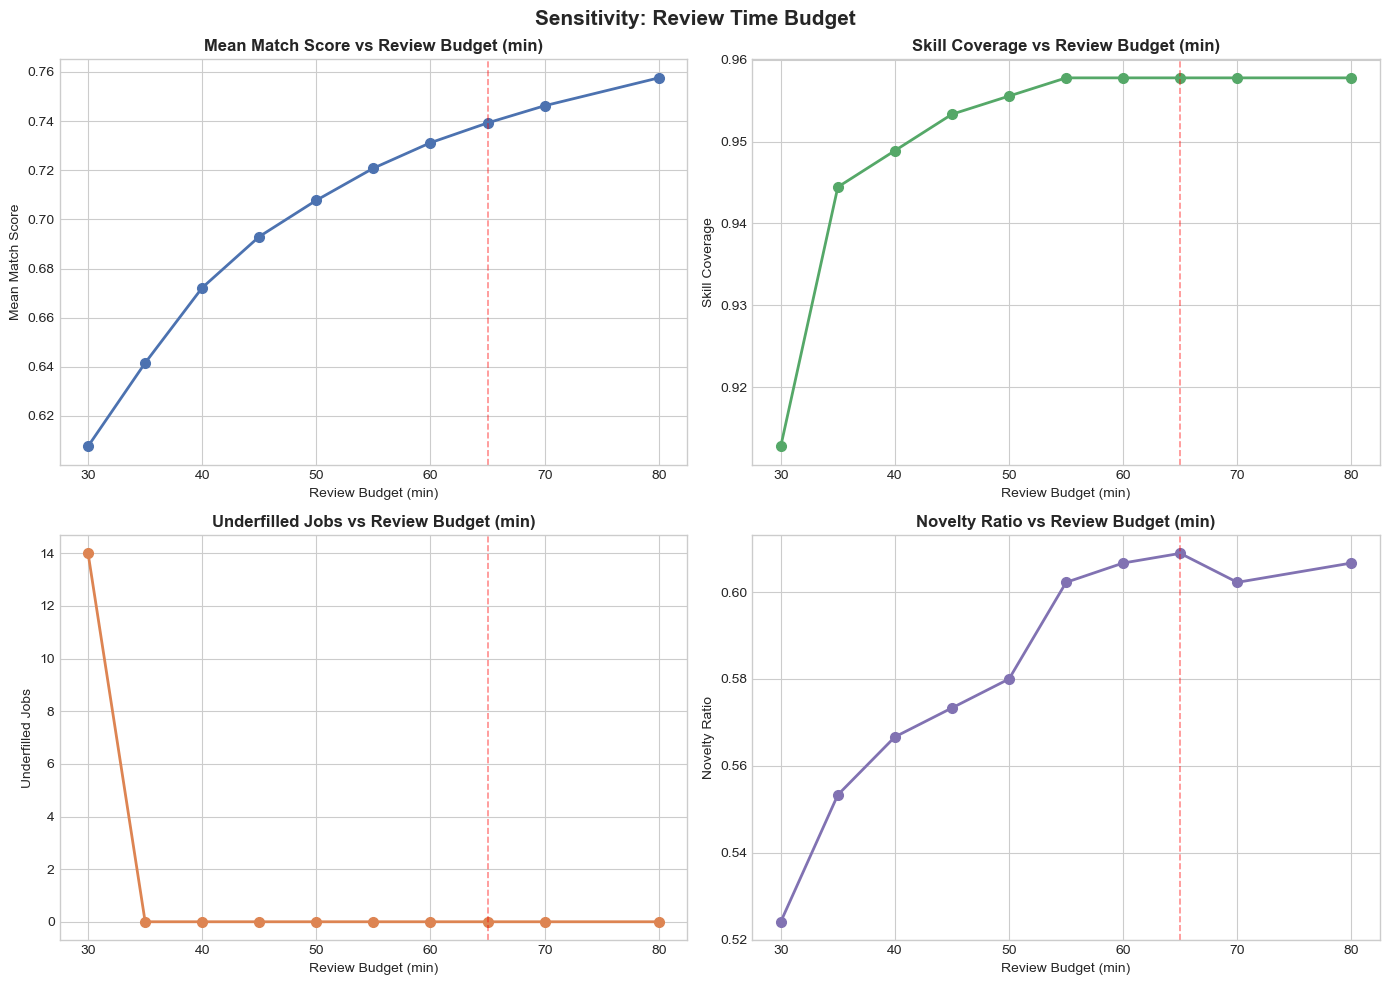

In [13]:
plot_sensitivity_2x2(
    budget_df,
    param="budget",
    xlabel="Review Budget (min)",
    base_value=BASE_BUDGET,
    title="Sensitivity: Review Time Budget",
    save_name="01_sensitivity_budget.png",
)

### 3.3 Experiment 2: Shortlist Size (k)

*"What happens when recruiters want bigger or smaller shortlists?"*

In [15]:
print("Sweeping shortlist size …")
k_values = [3, 4, 5, 6, 7, 8]
k_df = sensitivity_sweep("k", k_values, BASE_KWARGS, BEST_CONFIG)
display(k_df[["k", "mean_score", "mean_coverage", "underfilled", "total_selected", "novelty"]])

Sweeping shortlist size …
  k=3 … score=0.793, coverage=0.958, underfilled=0
  k=4 … score=0.769, coverage=0.958, underfilled=0
  k=5 … score=0.739, coverage=0.958, underfilled=0
  k=6 … score=0.707, coverage=0.958, underfilled=0
  k=7 … score=0.669, coverage=0.958, underfilled=0
  k=8 … score=0.629, coverage=0.953, underfilled=10


,k,mean_score,mean_coverage,underfilled,total_selected,novelty
0,3,0.7934,0.9578,0,270,0.6593
1,4,0.7688,0.9578,0,360,0.6333
2,5,0.7393,0.9578,0,450,0.6089
3,6,0.7072,0.9578,0,540,0.5704
4,7,0.6692,0.9578,0,630,0.5460
5,8,0.6286,0.9533,10,705,0.5106


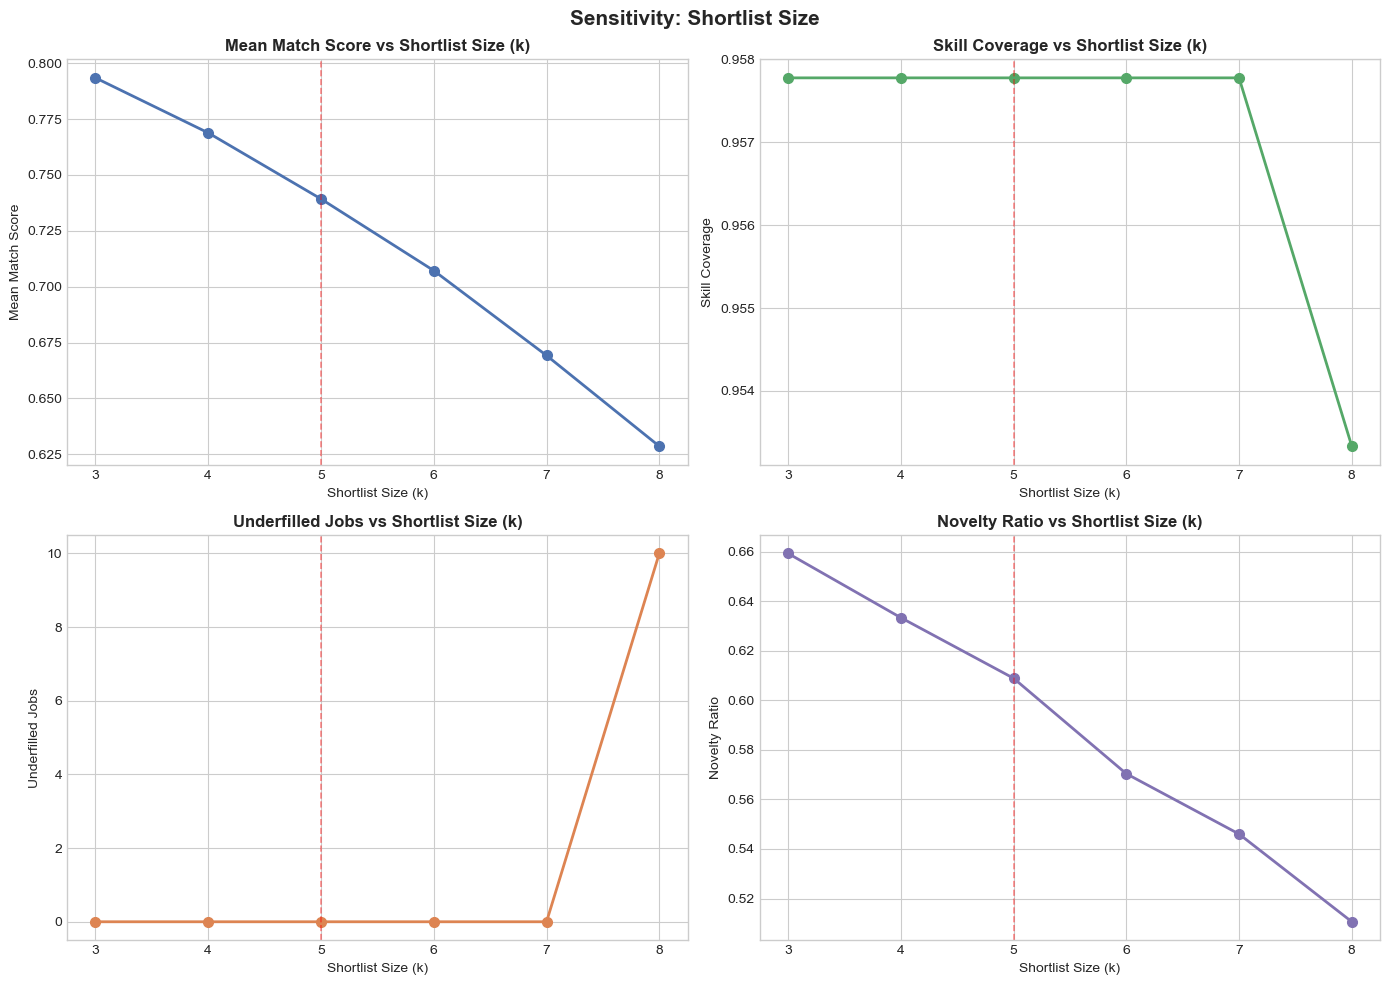

In [16]:
plot_sensitivity_2x2(
    k_df,
    param="k",
    xlabel="Shortlist Size (k)",
    base_value=5,
    title="Sensitivity: Shortlist Size",
    save_name="02_sensitivity_k.png",
)

### 3.4 Experiment 3: Candidate Exposure Cap

*"Should candidates be allowed on more shortlists? What's the trade-off?"*

In [18]:
print("Sweeping exposure cap …")
exposure_values = [1, 2, 3, 4, 5]
exp_df = sensitivity_sweep("max_exposure", exposure_values, BASE_KWARGS, BEST_CONFIG)
display(exp_df[["max_exposure", "mean_score", "mean_coverage", "underfilled", "novelty"]])

Sweeping exposure cap …
  max_exposure=1 … score=0.687, coverage=0.956, underfilled=0
  max_exposure=2 … score=0.739, coverage=0.958, underfilled=0
  max_exposure=3 … score=0.751, coverage=0.958, underfilled=0
  max_exposure=4 … score=0.756, coverage=0.958, underfilled=0
  max_exposure=5 … score=0.758, coverage=0.958, underfilled=0


,max_exposure,mean_score,mean_coverage,underfilled,novelty
0,1,0.6874,0.9556,0,1.0000
1,2,0.7393,0.9578,0,0.6089
2,3,0.7514,0.9578,0,0.5000
3,4,0.7559,0.9578,0,0.4511
4,5,0.7579,0.9578,0,0.4378


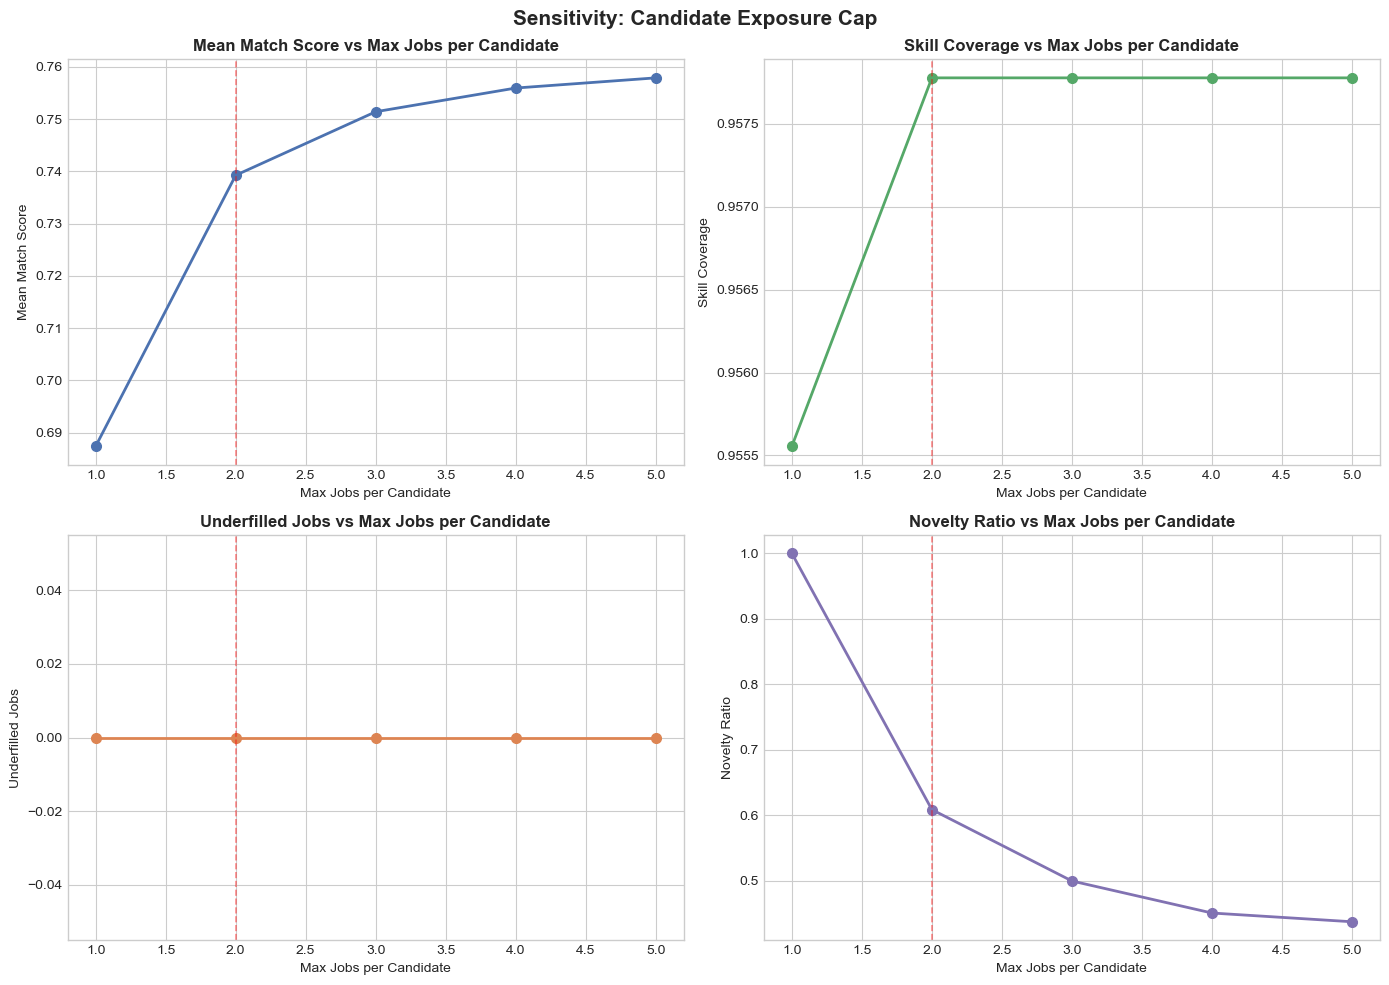

In [19]:
plot_sensitivity_2x2(
    exp_df,
    param="max_exposure",
    xlabel="Max Jobs per Candidate",
    base_value=2,
    title="Sensitivity: Candidate Exposure Cap",
    save_name="03_sensitivity_exposure.png",
)

### 3.5 Experiment 4: Quality Floor

*"How strict should the minimum match quality requirement be?"*

In [21]:
print("Sweeping quality floor …")
floor_values = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
floor_df = sensitivity_sweep("floor", floor_values, BASE_KWARGS, BEST_CONFIG)
display(floor_df[["floor", "mean_score", "mean_coverage", "underfilled", "novelty"]])

Sweeping quality floor …
  floor=0.2 … score=0.739, coverage=0.958, underfilled=0
  floor=0.25 … score=0.739, coverage=0.958, underfilled=0
  floor=0.3 … score=0.739, coverage=0.958, underfilled=0
  floor=0.35 … score=0.739, coverage=0.958, underfilled=0
  floor=0.4 … score=0.739, coverage=0.958, underfilled=0
  floor=0.45 … score=0.739, coverage=0.958, underfilled=0
  floor=0.5 … score=0.739, coverage=0.958, underfilled=0
  floor=0.55 … score=0.739, coverage=0.958, underfilled=0
  floor=0.6 … score=0.739, coverage=0.958, underfilled=0


,floor,mean_score,mean_coverage,underfilled,novelty
0,0.2000,0.7394,0.9578,0,0.6156
1,0.2500,0.7392,0.9578,0,0.6111
2,0.3000,0.7391,0.9578,0,0.6133
3,0.3500,0.7392,0.9578,0,0.6133
4,0.4000,0.7393,0.9578,0,0.6089
5,0.4500,0.7391,0.9578,0,0.6111
6,0.5000,0.7391,0.9578,0,0.6089
7,0.5500,0.7392,0.9578,0,0.6156
8,0.6000,0.7392,0.9578,0,0.6178


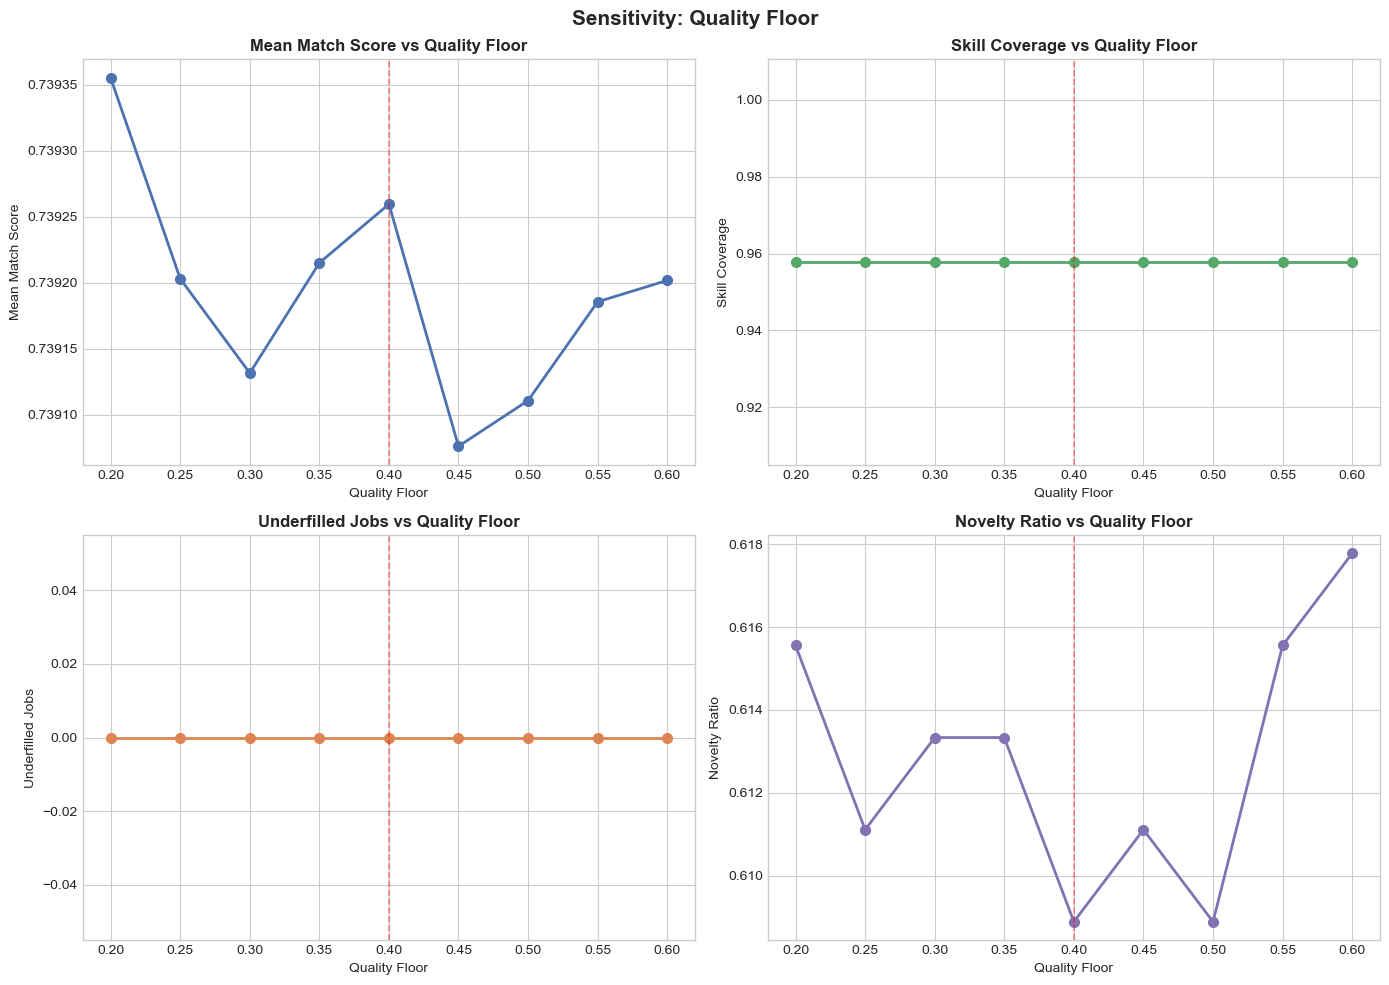

In [22]:
plot_sensitivity_2x2(
    floor_df,
    param="floor",
    xlabel="Quality Floor",
    base_value=BASE_FLOOR,
    title="Sensitivity: Quality Floor",
    save_name="04_sensitivity_floor.png",
)

## 4. Summary Dashboard
---
### Key Findings
#### Budget Sensitivity
- **Tightest constraint**: below ~40 min, the model is forced to pick short resumes over good ones, causing score and coverage to drop sharply
- **Diminishing returns**: above ~65 min, additional budget barely improves results — the model has already found the best candidates
- **Recommended**: 55–65 min provides the best quality-per-minute trade-off

#### Shortlist Size
- **Coverage improves** with larger shortlists (more candidates = more skill diversity)
- **Score decreases** as the model must dig deeper into the candidate pool
- **Novelty drops** since more candidates are needed total, increasing reuse pressure
- k = 5 balances these trade-offs well

#### Exposure Cap
- **cap = 1** means every candidate appears on at most one shortlist — high novelty but the model may struggle to fill all shortlists
- **cap ≥ 3** provides diminishing returns on score/coverage while novelty degrades
- cap = 2 is the sweet spot: enough flexibility for the optimiser without excessive reuse

#### Quality Floor
- **Low floor** (< 0.30): effectively inactive — the optimiser already prefers good candidates
- **High floor** (> 0.50): forces the model to leave jobs underfilled when the candidate pool is thin for certain roles
- 0.35–0.45 ensures a baseline quality without over-constraining

A single 4×4 figure showing all sensitivity experiments together.

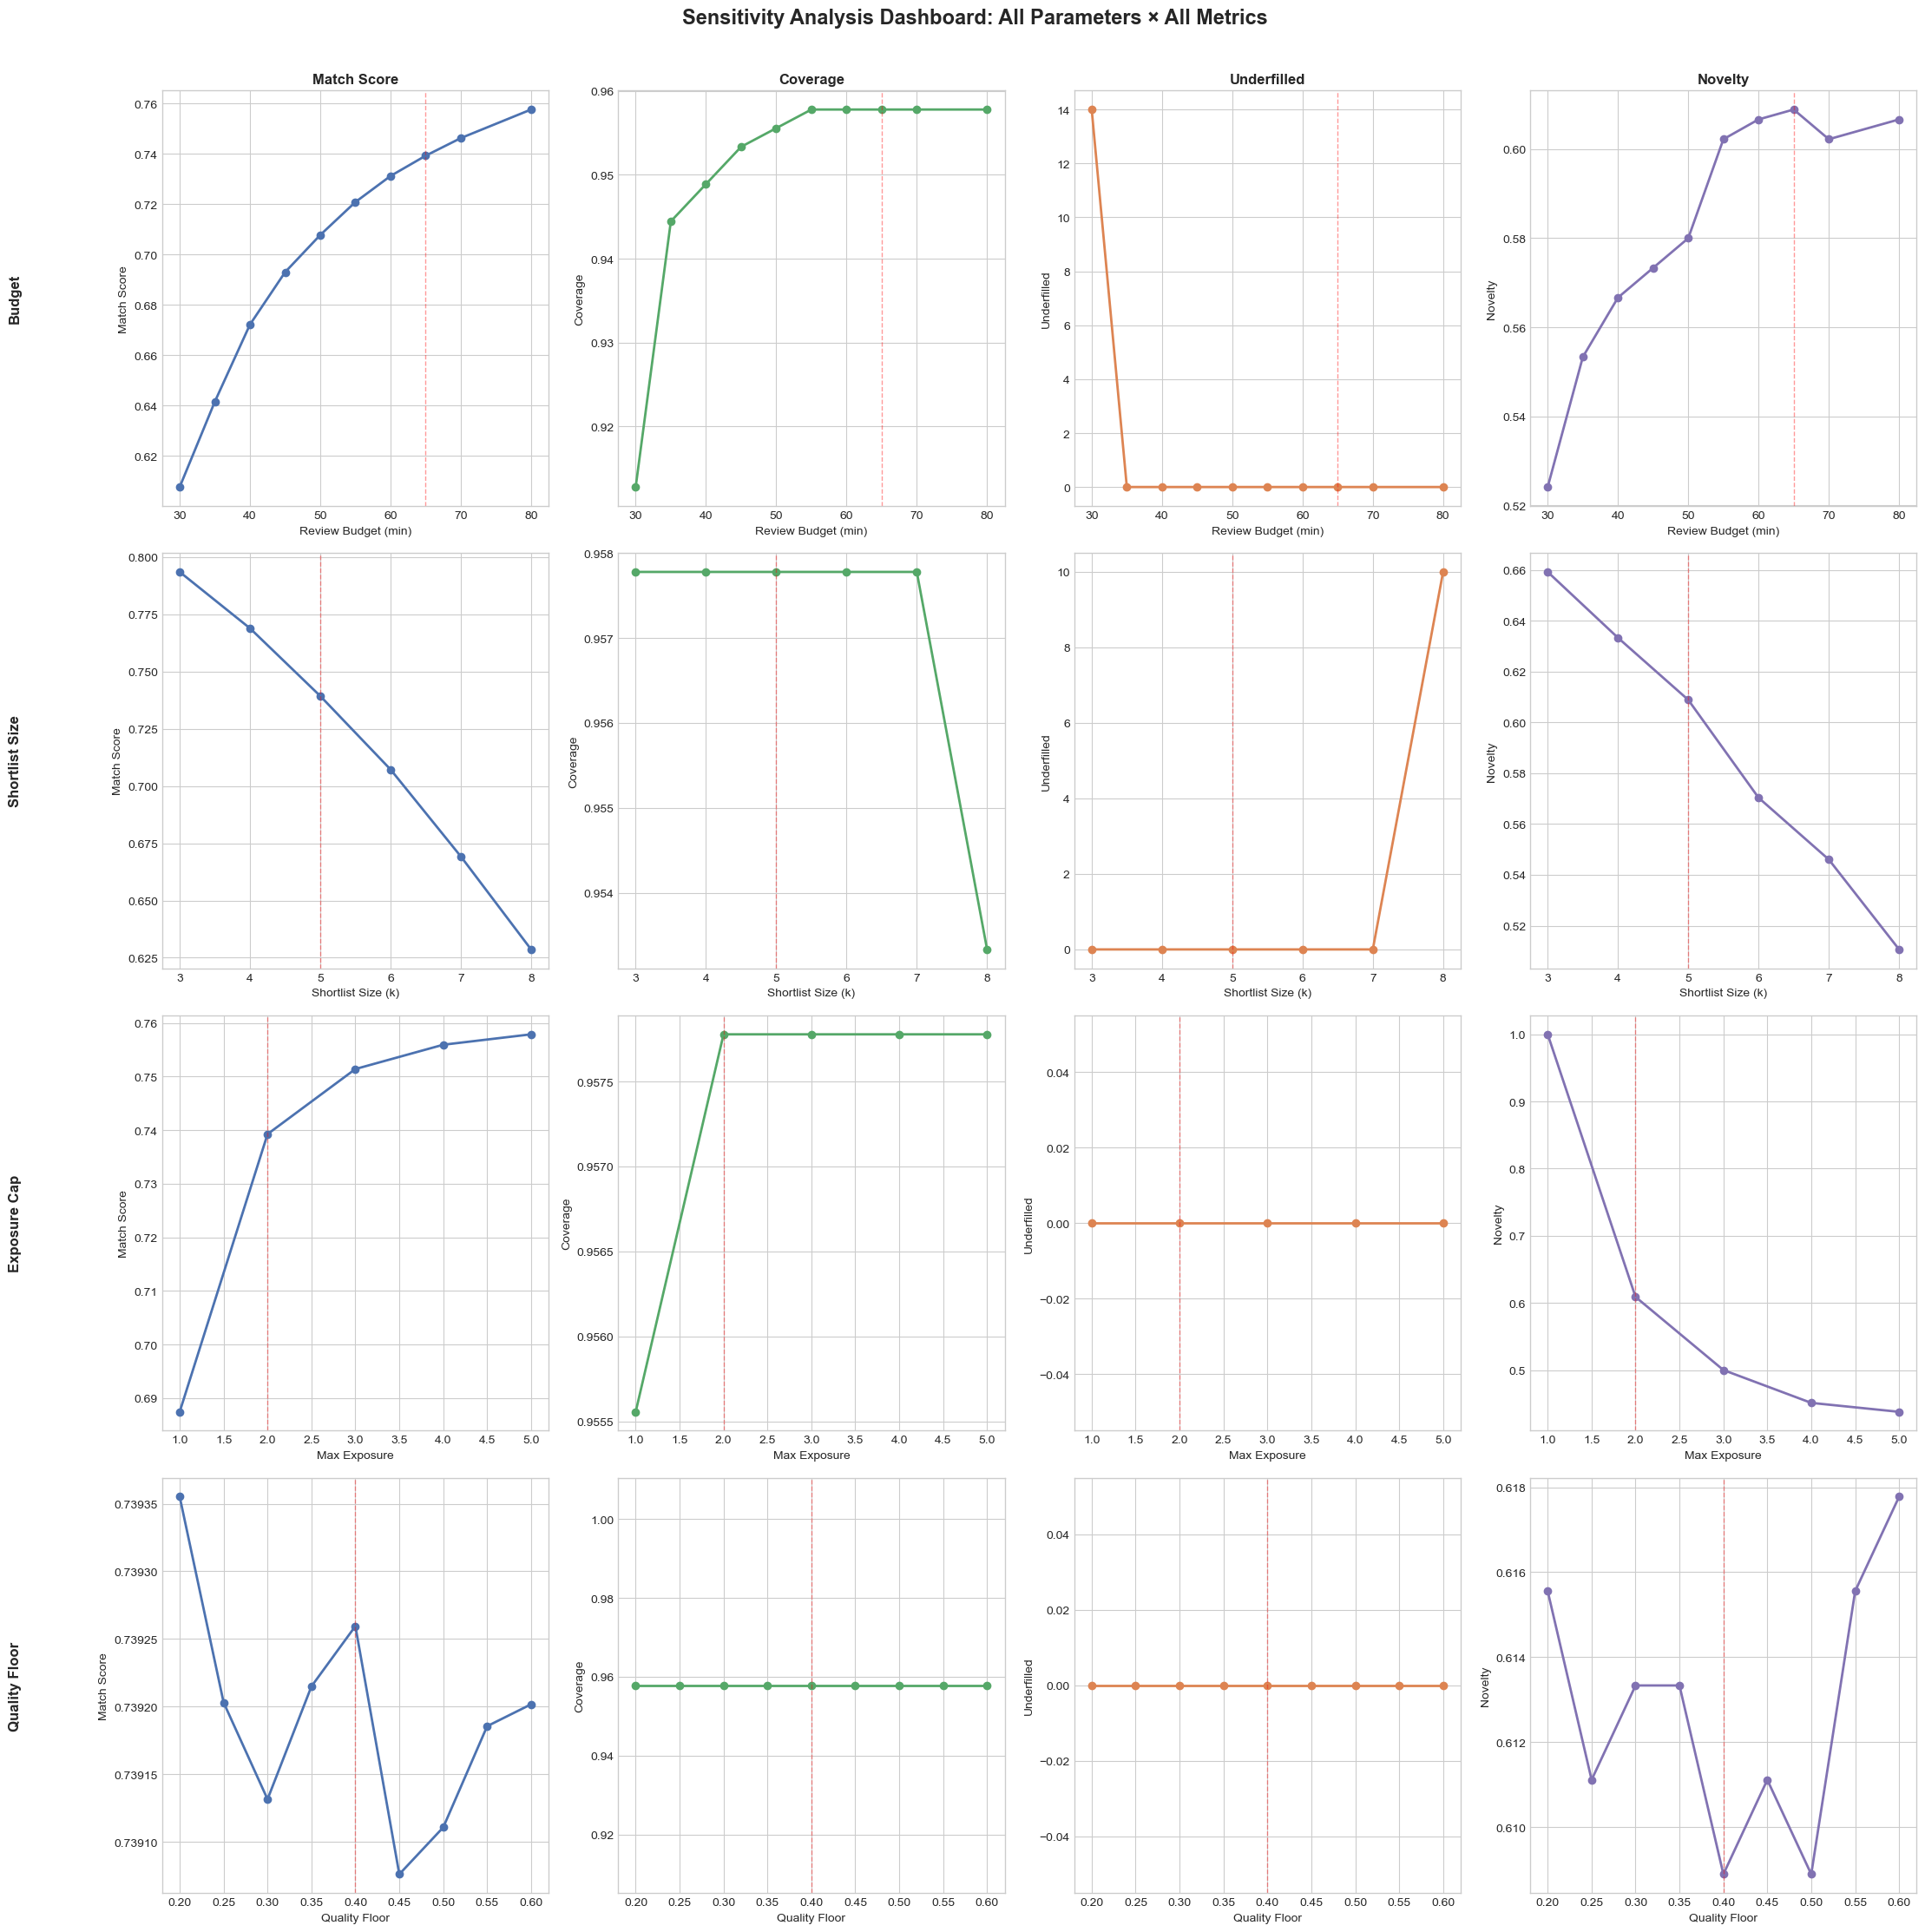

In [24]:
fig, axes = plt.subplots(4, 4, figsize=(22, 22))

dashboard_specs = [
    (budget_df, "budget", "Review Budget (min)", BASE_BUDGET, "Budget"),
    (k_df, "k", "Shortlist Size (k)", 5, "Shortlist Size"),
    (exp_df, "max_exposure", "Max Exposure", 2, "Exposure Cap"),
    (floor_df, "floor", "Quality Floor", BASE_FLOOR, "Quality Floor"),
]

metric_specs = [
    ("mean_score", "Match Score", "#4C72B0"),
    ("mean_coverage", "Coverage", "#55A868"),
    ("underfilled", "Underfilled", "#DD8452"),
    ("novelty", "Novelty", "#8172B2"),
]

for row, (df, param, xlabel, base, row_label) in enumerate(dashboard_specs):
    for col, (metric, col_label, colour) in enumerate(metric_specs):
        ax = axes[row, col]
        ax.plot(df[param], df[metric], "o-", color=colour, linewidth=2, markersize=6)
        if base is not None:
            ax.axvline(base, color="red", linestyle="--", alpha=0.4, linewidth=1)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(col_label)

        if row == 0:
            ax.set_title(col_label, fontsize=12, fontweight="bold")
        if col == 0:
            ax.text(
                -0.38, 0.5, row_label,
                transform=ax.transAxes,
                rotation=90,
                va="center", ha="center",
                fontsize=12, fontweight="bold"
            )

fig.suptitle("Sensitivity Analysis Dashboard: All Parameters × All Metrics", fontsize=17, fontweight="bold", y=1.01)
fig.tight_layout()
plt.savefig(OUT_DIR / "05_sensitivity_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Computational Feasibility at Scale

In [26]:
def solve_milp_subset(config, resume_ids, job_ids, budget=65.0, floor=0.40, k=5, max_exposure=2, time_limit=180):
    """
    Solve MILP on a subset of resumes/jobs to study computational scaling.
    Returns solve time and status.
    """
    if not HAS_GUROBI:
        return {"selected": [], "obj_val": 0, "solve_time": 0, "gap": None, "status": "no_gurobi"}

    resume_ids = sorted(list(resume_ids))
    job_ids = sorted(list(job_ids))
    subset_pairs = [(i, j) for i in resume_ids for j in job_ids if (i, j) in n_tfidf]

    t0 = time.perf_counter()
    m = gp.Model("SA_subset")
    m.Params.OutputFlag = 0
    m.Params.TimeLimit = time_limit
    m.Params.MIPGap = 0.01

    w = config

    x = {p: m.addVar(vtype=GRB.BINARY) for p in subset_pairs}
    u = {j: m.addVar(lb=0, ub=k) for j in job_ids}
    y = {}
    for j in job_ids:
        for s in job_req_skills.get(j, []):
            y[j, s] = m.addVar(vtype=GRB.BINARY)
    q = {j: m.addVar(lb=0) for j in job_ids}
    m.update()

    obj = gp.LinExpr()
    for (i, j), var in x.items():
        obj += pair_quality(i, j, w) * var
    for (j, s), var in y.items():
        obj += w["w_skill_cov"] * skill_weight.get((j, s), 1.0) * var
    for j in job_ids:
        obj -= w["w_underfill"] * u[j]
        obj -= w["w_quality"] * q[j]
    m.setObjective(obj, GRB.MAXIMIZE)

    # shortlist size + budget
    for j in job_ids:
        m.addConstr(gp.quicksum(x[i, j] for i in resume_ids if (i, j) in x) + u[j] == k)
        m.addConstr(gp.quicksum(review_time[i] * x[i, j] for i in resume_ids if (i, j) in x) <= budget)

    # exposure cap
    for i in resume_ids:
        m.addConstr(gp.quicksum(x[i, j] for j in job_ids if (i, j) in x) <= max_exposure)

    # skill coverage linking + quality floor
    for j in job_ids:
        for s in job_req_skills.get(j, []):
            if (j, s) in y:
                m.addConstr(
                    y[j, s] <= gp.quicksum(skill_has.get((i, j, s), 0) * x[i, j]
                                           for i in resume_ids if (i, j) in x)
                )

        m.addConstr(
            gp.quicksum(pair_quality(i, j, w) * x[i, j] for i in resume_ids if (i, j) in x) + q[j]
            >= floor * (k - u[j])
        )

    # anti-redundancy
    for j in job_ids:
        for cid, members in cluster_members.items():
            eligible = [i for i in members if i in resume_ids and (i, j) in x]
            if len(eligible) > 1:
                m.addConstr(gp.quicksum(x[i, j] for i in eligible) <= 1)

    m.optimize()
    solve_time = time.perf_counter() - t0

    status = m.Status
    if status in (GRB.OPTIMAL, GRB.TIME_LIMIT) and m.SolCount > 0:
        selected = [(i, j) for (i, j), var in x.items() if var.X > 0.5]
        return {
            "selected": selected,
            "obj_val": m.ObjVal,
            "solve_time": solve_time,
            "gap": m.MIPGap if hasattr(m, "MIPGap") else None,
            "status": status,
        }

    return {
        "selected": [],
        "obj_val": 0,
        "solve_time": solve_time,
        "gap": None,
        "status": status,
    }

In [27]:
# Nested subsets for scaling experiment
rng_res = np.random.RandomState(RANDOM_SEED)
rng_job = np.random.RandomState(RANDOM_SEED + 1)

resume_order = rng_res.permutation(ALL_RESUMES)
job_order = rng_job.permutation(ALL_JOBS)

scaling_grid = [
    (100, 20),
    (150, 30),
    (200, 40),
    (250, 50),
    (300, 60),
    (400, 75),
    (500, 90),
]

scaling_rows = []

print("Running computational scaling experiment ...")
for n_resumes, n_jobs in scaling_grid:
    sub_resumes = resume_order[:n_resumes]
    sub_jobs = job_order[:n_jobs]

    result = solve_milp_subset(
        BEST_CONFIG,
        resume_ids=sub_resumes,
        job_ids=sub_jobs,
        budget=BASE_BUDGET,
        floor=BASE_FLOOR,
        k=5,
        max_exposure=2,
        time_limit=180,
    )

    scaling_rows.append({
        "n_resumes": n_resumes,
        "n_jobs": n_jobs,
        "num_pairs": n_resumes * n_jobs,
        "solve_time_sec": result["solve_time"],
        "status": result["status"],
        "gap": result["gap"],
        "selected_pairs": len(result["selected"]),
    })

    print(f"  resumes={n_resumes}, jobs={n_jobs}, pairs={n_resumes*n_jobs:,}, time={result['solve_time']:.2f}s")

scaling_df = pd.DataFrame(scaling_rows)
display(scaling_df)

Running computational scaling experiment ...
  resumes=100, jobs=20, pairs=2,000, time=0.24s
  resumes=150, jobs=30, pairs=4,500, time=0.49s
  resumes=200, jobs=40, pairs=8,000, time=0.68s
  resumes=250, jobs=50, pairs=12,500, time=1.22s
  resumes=300, jobs=60, pairs=18,000, time=2.35s
  resumes=400, jobs=75, pairs=30,000, time=3.02s
  resumes=500, jobs=90, pairs=45,000, time=4.43s


,n_resumes,n_jobs,num_pairs,solve_time_sec,status,gap,selected_pairs
0,100,20,2000,0.2423,2,0.0088,100
1,150,30,4500,0.4905,2,0.0100,150
2,200,40,8000,0.6809,2,0.0091,200
3,250,50,12500,1.2215,2,0.0089,250
4,300,60,18000,2.3530,2,0.0072,300
5,400,75,30000,3.0172,2,0.0100,375
6,500,90,45000,4.4297,2,0.0068,450


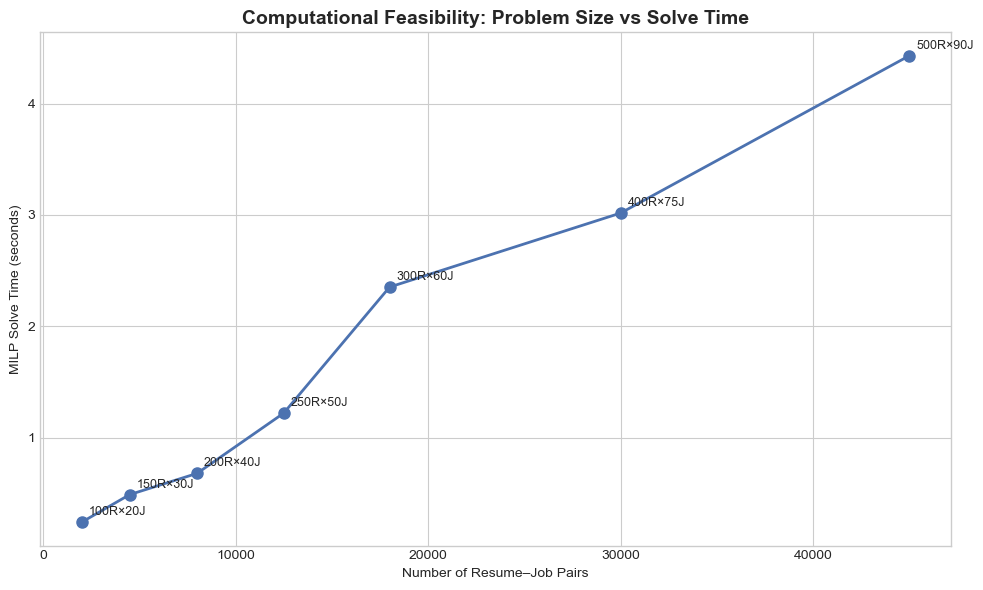

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    scaling_df["num_pairs"],
    scaling_df["solve_time_sec"],
    "o-",
    color="#4C72B0",
    linewidth=2,
    markersize=8
)

for _, row in scaling_df.iterrows():
    ax.annotate(
        f"{int(row['n_resumes'])}R×{int(row['n_jobs'])}J",
        (row["num_pairs"], row["solve_time_sec"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9
    )

ax.set_xlabel("Number of Resume–Job Pairs")
ax.set_ylabel("MILP Solve Time (seconds)")
ax.set_title("Computational Feasibility: Problem Size vs Solve Time", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.savefig(OUT_DIR / "06_scaling_pairs_vs_time.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Save Results

In [30]:
budget_df.to_csv(OUT_DIR / "sensitivity_budget.csv", index=False)
k_df.to_csv(OUT_DIR / "sensitivity_k.csv", index=False)
exp_df.to_csv(OUT_DIR / "sensitivity_exposure.csv", index=False)
floor_df.to_csv(OUT_DIR / "sensitivity_floor.csv", index=False)
scaling_df.to_csv(OUT_DIR / "sensitivity_scaling_pairs_vs_time.csv", index=False)

print("Saved:")
for f in sorted(OUT_DIR.glob("*")):
    print(f"  {f.name}")

Saved:
  01_extraction_coverage.png
  01_method_comparison.png
  01_sensitivity_budget.png
  02_job_title_distribution.png
  02_sensitivity_k.png
  02_sweep_results.png
  03_sensitivity_exposure.png
  03_word_count_distributions.png
  04_sensitivity_floor.png
  04_skills_analysis.png
  05_experience_education.png
  05_sensitivity_dashboard.png
  06_redundancy_sweep.png
  06_scaling_pairs_vs_time.png
  07_redundancy_clusters.png
  best_config.json
  greedy_selected.csv
  method_comparison.csv
  milp_best_selected.csv
  milp_case_jobs.csv
  milp_case_pairs.csv
  milp_job_diagnostics.csv
  milp_pair_decisions_detailed.csv
  milp_q_values.csv
  milp_u_values.csv
  milp_x_values.csv
  milp_y_values.csv
  scoreonly_selected.csv
  sensitivity_budget.csv
  sensitivity_exposure.csv
  sensitivity_floor.csv
  sensitivity_k.csv
  sensitivity_scaling_pairs_vs_time.csv
  sweep_results.csv
